<a href="https://colab.research.google.com/github/yosbel-penate2/leak-algorithm-experiments/blob/main/bioinspired_leak_pdm_experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# # Algoritmo de la Gotera – Separación espacial ruido/anomalías

import numpy as np, matplotlib.pyplot as plt

np.random.seed(42)

n = 100
x_ref = 75.0
gamma = 0.1           # para ruido (central)
beta = 5.0
fe = 0.02
fd = 0.15            # degradación agresiva si h>0
fr = 0.02
h_sat = 10.0         # derrame por saturación
D_crit = 30.0
train_steps = 2000
total_steps = 10000
xi_big = 1.5         # umbral: xi >= 1.5 → anomalía (va a extremos)

def cell_index_central(xi):
    """Mapea desviaciones pequeñas al centro (celdas 40-60)."""
    val = (n / 2) * (1 + np.tanh(gamma * xi))
    idx = int(np.floor(val)) + 1
    return min(60, max(41, idx)) - 1   # restringir a 40..59

def cell_index_extreme(xi):
    """Mapea anomalías grandes a extremos: positivas a la derecha (80-99)."""
    # Para xi positivo grande, cerca de n
    idx = int(80 + (xi - xi_big) * 4)  # escalado rápido
    return min(n, max(80, idx)) - 1

def internal_update(h, v, b):
    h = h + b
    b = np.zeros(n)
    # Degradación si h>0
    v = np.where(h > 0, v - fd, v)
    v = np.clip(v, 0, 100)
    h = np.clip(h - fe, 0, None)
    # Derrame por saturación
    for i in range(n):
        if h[i] > h_sat:
            ex = h[i] - h_sat
            h[i] = h_sat
            if i > 0 and i < n-1:
                h[i-1] += ex/2; h[i+1] += ex/2
            elif i == 0 and n>1: h[1] += ex
            elif i == n-1 and n>1: h[n-2] += ex
    v = np.where(v < 100, np.minimum(v + fr, 100), v)
    return h, v, b

def run_scenario(signal, xi_big=1.5):
    h = np.zeros(n); v = np.full(n, 100.0); b = np.zeros(n)
    # Entrenamiento solo con ruido (xi < xi_big) → celda central
    for k in range(train_steps):
        xi = signal[k] - x_ref
        if 0 < xi < xi_big:      # solo ruido pequeño
            T = beta * xi
            I = cell_index_central(xi)
            b[I] += T
        h, v, b = internal_update(h, v, b)
    l_imperv = 100.0 - v
    l_imperv = np.minimum(l_imperv, 80.0)   # tope 80%
    # Reinicio operativo
    h = np.zeros(n); v = np.full(n, 100.0); b = np.zeros(n)
    D_vals = np.zeros(total_steps - train_steps)
    alarm_step = None
    for k in range(train_steps, total_steps):
        xi = signal[k] - x_ref
        if xi > 0:
            T = beta * xi
            if xi < xi_big:                # ruido
                I = cell_index_central(xi)
                T_eff = T * (1 - l_imperv[I]/100)
            else:                          # anomalía grande
                I = cell_index_extreme(xi)
                T_eff = T                  # sin atenuación (zona no entrenada)
            b[I] += T_eff
        h, v, b = internal_update(h, v, b)
        Dk = np.mean(100 - v)
        D_vals[k - train_steps] = Dk
        if alarm_step is None and Dk >= D_crit:
            alarm_step = k
    return D_vals, np.mean(100 - v), alarm_step, l_imperv, v

# Señales
np.random.seed(123)
noise = np.random.normal(0, 0.5, total_steps)
clean = x_ref + noise

D1, Df1, al1, l1, v1 = run_scenario(clean.copy(), xi_big)

np.random.seed(456)
t2 = np.random.choice(range(train_steps, total_steps), 120, replace=False)
amp2 = np.random.uniform(1, 5, 120)
sig2 = clean.copy()
for t,a in zip(t2, amp2): sig2[t] += a
D2, Df2, al2, l2, v2 = run_scenario(sig2, xi_big)

np.random.seed(789)
t3 = np.random.choice(range(train_steps, total_steps), 25, replace=False)
amp3 = np.random.uniform(1, 5, 25)
sig3 = clean.copy()
for t,a in zip(t3, amp3): sig3[t] += a
D3, Df3, al3, l3, v3 = run_scenario(sig3, xi_big)

# Informe
import json
report = {
    "parametros": {"n":n,"x_ref":x_ref,"beta":beta,"gamma":gamma,"fe":fe,"fd":fd,"fr":fr,"h_sat":h_sat,"D_crit":D_crit,"train_steps":train_steps,"total_steps":total_steps,"xi_big":xi_big},
    "escenarios": {
        "1_normal": {"anomalias":0,"D_final":round(Df1,2),"alarma_paso":al1,"D_max":round(float(np.max(D1)),2),"capa_imperv":{"min":round(float(np.min(l1)),2),"max":round(float(np.max(l1)),2),"media":round(float(np.mean(l1)),2)},"vida_final":{"min":round(float(np.min(v1)),2),"max":round(float(np.max(v1)),2),"media":round(float(np.mean(v1)),2)}},
        "2_degradacion": {"anomalias":120,"amp_media":round(float(np.mean(amp2)),2),"D_final":round(Df2,2),"alarma_paso":al2,"D_max":round(float(np.max(D2)),2),"capa_imperv":{"min":round(float(np.min(l2)),2),"max":round(float(np.max(l2)),2),"media":round(float(np.mean(l2)),2)},"vida_final":{"min":round(float(np.min(v2)),2),"max":round(float(np.max(v2)),2),"media":round(float(np.mean(v2)),2)},"vector_vida_final":[round(float(vi),1) for vi in v2]},
        "3_picos_raros": {"anomalias":25,"amp_media":round(float(np.mean(amp3)),2),"D_final":round(Df3,2),"alarma_paso":al3,"D_max":round(float(np.max(D3)),2),"capa_imperv":{"min":round(float(np.min(l3)),2),"max":round(float(np.max(l3)),2),"media":round(float(np.mean(l3)),2)},"vida_final":{"min":round(float(np.min(v3)),2),"max":round(float(np.max(v3)),2),"media":round(float(np.mean(v3)),2)}}
    }
}
print("----- INFORME DE RESULTADOS (JSON) -----")
print(json.dumps(report, indent=2, ensure_ascii=False))

----- INFORME DE RESULTADOS (JSON) -----
{
  "parametros": {
    "n": 100,
    "x_ref": 75.0,
    "beta": 5.0,
    "gamma": 0.1,
    "fe": 0.02,
    "fd": 0.15,
    "fr": 0.02,
    "h_sat": 10.0,
    "D_crit": 30.0,
    "train_steps": 2000,
    "total_steps": 10000,
    "xi_big": 1.5
  },
  "escenarios": {
    "1_normal": {
      "anomalias": 0,
      "D_final": 12.33,
      "alarma_paso": null,
      "D_max": 12.65,
      "capa_imperv": {
        "min": 0.0,
        "max": 80.0,
        "media": 35.6
      },
      "vida_final": {
        "min": 0.02,
        "max": 100.0,
        "media": 87.67
      }
    },
    "2_degradacion": {
      "anomalias": 120,
      "amp_media": 3.12,
      "D_final": 27.2,
      "alarma_paso": null,
      "D_max": 27.59,
      "capa_imperv": {
        "min": 0.0,
        "max": 80.0,
        "media": 35.6
      },
      "vida_final": {
        "min": 0.02,
        "max": 100.0,
        "media": 72.8
      },
      "vector_vida_final": [
        100.0,
  

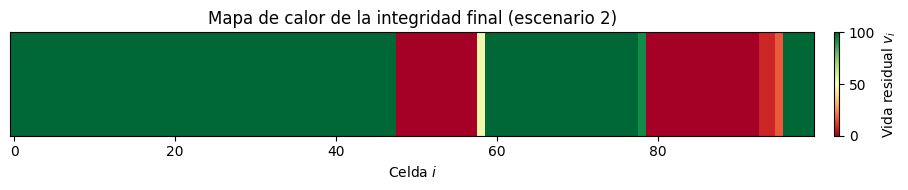

In [10]:
# ## Visualización de resultados

import matplotlib.pyplot as plt

# ---------- 1. Evolución del índice de desgaste D_k en los tres escenarios ----------
fig1, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(D1, label='Normal (0 anomalías)', linewidth=1.5)
ax1.plot(D2, label='Degradación progresiva (120)', linewidth=1.5)
ax1.plot(D3, label='Picos raros (25)', linewidth=1.5)
ax1.axhline(D_crit, color='red', linestyle='--', linewidth=1, label=f'Umbral crítico ($D_{{\\mathrm{{crit}}}} = {D_crit}$)')
ax1.set_xlabel('Paso (fase de prueba)')
ax1.set_ylabel('Índice de desgaste $D_k$')
ax1.set_title('Evolución del índice integral de desgaste')
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ---------- 2. Distribución final de la vida (escenario 2) ----------
fig2, ax2 = plt.subplots(figsize=(10, 4))
ax2.bar(range(1, n+1), v2, color='saddlebrown', edgecolor='black', linewidth=0.2)
ax2.axhline(100, color='green', linestyle='--', linewidth=0.8, alpha=0.5)
ax2.set_xlabel('Celda $i$')
ax2.set_ylabel('Vida residual $v_i$')
ax2.set_title('Distribución final de integridad estructural (escenario 2)')
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ---------- 3. Comparación de D_final entre escenarios ----------
fig3, ax3 = plt.subplots(figsize=(6, 5))
scenarios = ['Normal', 'Degradación\nprogresiva', 'Picos raros']
D_finals = [Df1, Df2, Df3]
colors = ['green', 'red', 'orange']
bars = ax3.bar(scenarios, D_finals, color=colors, alpha=0.7)
ax3.axhline(D_crit, color='red', linestyle='--', linewidth=1, label=f'Umbral crítico = {D_crit}')
ax3.set_ylabel('$D_{\\mathrm{final}}$')
ax3.set_title('Desgaste acumulado al final del experimento')
# Añadir etiquetas encima de las barras
for bar, val in zip(bars, D_finals):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}', ha='center', fontweight='bold')
ax3.legend()
plt.tight_layout()
plt.show()

# ---------- 4. Capa impermeabilizante (escenario 2) ----------
fig4, ax4 = plt.subplots(figsize=(10, 4))
ax4.bar(range(1, n+1), l2, color='blue', alpha=0.6, label='Impermeabilidad $l_i$')
ax4.set_xlabel('Celda $i$')
ax4.set_ylabel('$l_i$ (%)')
ax4.set_title('Capa impermeabilizante después del entrenamiento (escenario 2)')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ---------- 5. Mapa de calor de la vida final (opcional, para ver la zona dañada) ----------
fig5, ax5 = plt.subplots(figsize=(10, 2))
heatmap_data = v2.reshape(1, -1)
im = ax5.imshow(heatmap_data, aspect='auto', cmap='RdYlGn', vmin=0, vmax=100)
ax5.set_yticks([])
ax5.set_xlabel('Celda $i$')
ax5.set_title('Mapa de calor de la integridad final (escenario 2)')
cbar = plt.colorbar(im, ax=ax5, orientation='vertical', pad=0.02)
cbar.set_label('Vida residual $v_i$')
plt.tight_layout()
plt.show()